# Klasifikasi Kematangan Tapai - Support Vector Machine (SVM)

Notebook ini menggunakan **Support Vector Machine (SVM)** dari scikit-learn untuk memprediksi status kematangan tapai berdasarkan data sensor.

## Dataset
- **Fitur:** `jam`, `suhu`, `kelembaban`, `kadar_gas`
- **Target:** `status_kematangan` (belum matang, matang, terlalu matang)
- **10 percobaan**, masing-masing 60 jam pengamatan

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA

plt.style.use('seaborn-v0_8')
print('Libraries loaded successfully')

Libraries loaded successfully


## 1. Load & Eksplorasi Data

In [4]:
df = pd.read_csv('../dataset/dataset_kematangan_tapai_v2.csv')
print('Shape:', df.shape)
df.head(10)

Shape: (600, 6)


,percobaan,jam,suhu,kelembaban,kadar_gas,status_kematangan
0,1,1,28.73,78.77,0.02,belum matang
1,1,2,28.51,78.62,0.01,belum matang
2,1,3,28.33,78.22,0.01,belum matang
3,1,4,29.20,78.46,0.01,belum matang
4,1,5,28.42,78.65,0.00,belum matang
5,1,6,28.48,78.93,0.02,belum matang
6,1,7,28.99,78.87,0.01,belum matang
7,1,8,28.50,79.07,0.01,belum matang
8,1,9,28.48,78.72,0.01,belum matang
9,1,10,28.53,78.97,0.01,belum matang


Distribusi label:
status_kematangan
belum matang      417
terlalu matang    116
matang             67
Name: count, dtype: int64


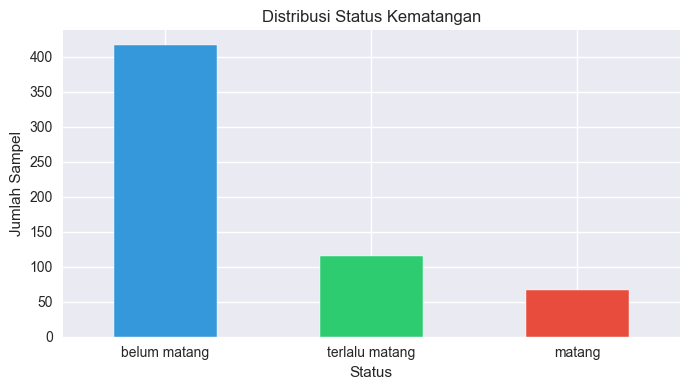

In [5]:
print('Distribusi label:')
counts = df['status_kematangan'].value_counts()
print(counts)

fig, ax = plt.subplots(figsize=(7, 4))
counts.plot(kind='bar', color=['#3498db', '#2ecc71', '#e74c3c'], edgecolor='white', ax=ax)
ax.set_title('Distribusi Status Kematangan')
ax.set_xlabel('Status')
ax.set_ylabel('Jumlah Sampel')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('plot_svm_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

## 2. Preprocessing

In [6]:
label_map = {'belum matang': 0, 'matang': 1, 'terlalu matang': 2}
df['label'] = df['status_kematangan'].map(label_map)

X = df[['jam', 'suhu', 'kelembaban', 'kadar_gas']].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}')

Train: (480, 4), Test: (120, 4)


## 3. Training SVM dengan Berbagai Kernel

In [7]:
kernels = ['linear', 'rbf', 'poly', 'sigmoid']
results = {}

for kernel in kernels:
    svm = SVC(kernel=kernel, C=1.0, random_state=42)
    svm.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, svm.predict(X_test_scaled))
    cv_scores = cross_val_score(svm, X_train_scaled, y_train, cv=5)
    results[kernel] = {'accuracy': acc, 'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std()}
    print(f'Kernel={kernel:8s} | Test Acc: {acc:.4f} | CV: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

best_kernel = max(results, key=lambda k: results[k]['accuracy'])
print(f'\nBest kernel: {best_kernel} (accuracy={results[best_kernel]["accuracy"]:.4f})')

Kernel=linear   | Test Acc: 0.9250 | CV: 0.9417 ± 0.0141
Kernel=rbf      | Test Acc: 0.9250 | CV: 0.9250 ± 0.0241
Kernel=poly     | Test Acc: 0.9250 | CV: 0.9208 ± 0.0313
Kernel=sigmoid  | Test Acc: 0.8000 | CV: 0.8167 ± 0.0252

Best kernel: linear (accuracy=0.9250)


## 4. Hyperparameter Tuning (GridSearch)

In [8]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1]
}

grid_search = GridSearchCV(
    SVC(kernel='rbf', random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_scaled, y_train)

print(f'Best params: {grid_search.best_params_}')
print(f'Best CV score: {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params: {'C': 100, 'gamma': 0.01}
Best CV score: 0.9375


In [9]:
best_svm = grid_search.best_estimator_
y_pred = best_svm.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print(f'Test Accuracy (best SVM): {accuracy:.4f} ({accuracy*100:.2f}%)')

target_names = ['belum matang', 'matang', 'terlalu matang']
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=target_names))

Test Accuracy (best SVM): 0.9250 (92.50%)

Classification Report:
                precision    recall  f1-score   support

  belum matang       0.98      0.98      0.98        84
        matang       0.62      0.77      0.69        13
terlalu matang       0.95      0.83      0.88        23

      accuracy                           0.93       120
     macro avg       0.85      0.86      0.85       120
  weighted avg       0.93      0.93      0.93       120



## 5. Confusion Matrix

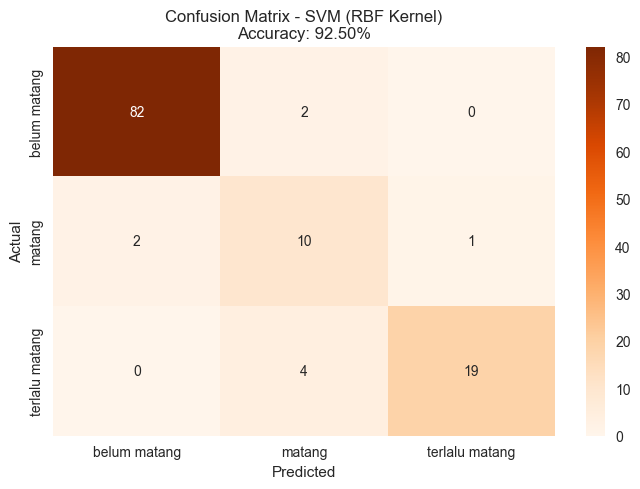

In [10]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=target_names, yticklabels=target_names, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix - SVM (RBF Kernel)\nAccuracy: {accuracy*100:.2f}%')
plt.tight_layout()
plt.savefig('plot_svm_cm.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Visualisasi Decision Boundary (PCA 2D)

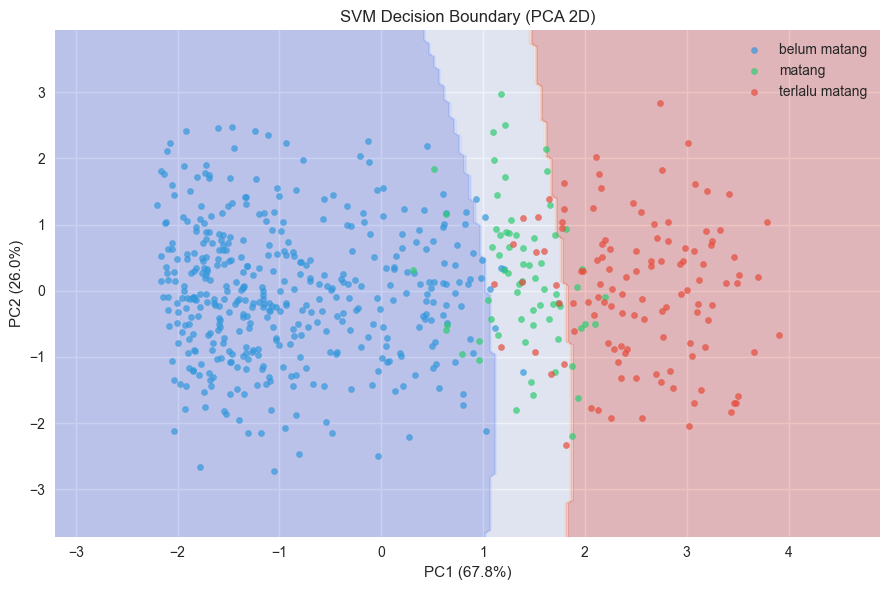

In [11]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(scaler.transform(X))

svm_2d = SVC(kernel='rbf', C=grid_search.best_params_['C'],
             gamma=grid_search.best_params_['gamma'], random_state=42)
svm_2d.fit(X_pca, y)

h = 0.05
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(9, 6))
ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
scatter_colors = ['#3498db', '#2ecc71', '#e74c3c']
for i, (label, color) in enumerate(zip(target_names, scatter_colors)):
    mask = y == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, label=label, s=20, alpha=0.7)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('SVM Decision Boundary (PCA 2D)')
ax.legend()
plt.tight_layout()
plt.savefig('plot_svm_boundary.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Kesimpulan

SVM dengan kernel RBF mampu menangkap **batas keputusan non-linear** antara kelas kematangan. Namun, seperti Logistic Regression, SVM juga memperlakukan setiap observasi jam secara **independen** tanpa mempertimbangkan konteks urutan waktu fermentasi sebelumnya — yang merupakan keterbatasan signifikan untuk data deret waktu ini.